In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_info_columns', 200)

df = pd.read_parquet('../../data/processed/crimes_features.parquet')
df.head()

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,hour_occ,year,month,day_of_week,hour_bins,age_group,crime_category,report_delay,is_domestic
0,1307355,2010-02-20,2010-02-20,13,Newton,1385,2,900,VIOLATION OF COURT ORDER,0913 1814 2000,48.0,M,H,501.0,SINGLE FAMILY DWELLING,0.0,No Weapon,AA,Adult Arrest,900.0,300 E GAGE AV,33.9825,-118.2695,13,2010,2,Saturday,Afternoon,Adult,person,0,False
1,11401303,2010-09-13,2010-09-12,14,Pacific,1485,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,NaN,M,W,101.0,STREET,0.0,No Weapon,IC,Invest Cont,740.0,SEPULVEDA BL,33.9599,-118.3962,0,2010,9,Sunday,Night,NaN,property,1,False
2,70309629,2010-08-09,2010-08-09,13,Newton,1324,2,946,OTHER MISCELLANEOUS CRIME,0344,NaN,M,H,103.0,ALLEY,0.0,No Weapon,IC,Invest Cont,946.0,1300 E 21ST ST,34.0224,-118.2524,15,2010,8,Monday,Afternoon,NaN,other,0,False
3,90631215,2010-01-05,2010-01-05,6,Hollywood,646,2,900,VIOLATION OF COURT ORDER,1100 0400 1402,47.0,F,W,101.0,STREET,102.0,HAND GUN,IC,Invest Cont,900.0,CAHUENGA BL,34.1016,-118.3295,1,2010,1,Tuesday,Night,Adult,person,0,False
4,100100501,2010-01-03,2010-01-02,1,Central,176,1,122,"RAPE, ATTEMPTED",0400,47.0,F,H,103.0,ALLEY,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,122.0,8TH ST,34.0387,-118.2488,21,2010,1,Saturday,Late Night,Adult,person,1,False


# 09 — EDA Blocco 5: Efficacia della risposta

**Fase PACE**: Analyze  
**Obiettivo**: analizzare l'efficacia della risposta delle forze dell'ordine 
attraverso il clearance rate (tasso di risoluzione dei casi) e il report 
delay (ritardo nella denuncia dei crimini).

**Input**: `data/processed/crimes_features.parquet`

**Domande a cui rispondiamo**:
- Q5.1 — Clearance rate per categoria di crimine e per area LAPD
- Q5.2 — Analisi del report delay: distribuzione e pattern per categoria

### Q5.1 — Clearance Rate per categoria di crimine

In [4]:
q51_df = df[['AREA NAME', 'Status Desc', 'crime_category']].copy()

print(q51_df.head(10))

   AREA NAME   Status Desc crime_category
0     Newton  Adult Arrest         person
1    Pacific   Invest Cont       property
2     Newton   Invest Cont          other
3  Hollywood   Invest Cont         person
4    Central   Invest Cont         person
5    Central  Adult Arrest       property
6    Central   Invest Cont       property
7    Central  Adult Arrest         person
8    Central   Invest Cont         person
9    Central   Invest Cont       property


In [3]:
q51_df['Status Desc'].unique()

array(['Adult Arrest', 'Invest Cont', 'Adult Other', 'Juv Arrest',
       'Juv Other', 'UNK'], dtype=object)

In [8]:
cleared_statuses = ['Adult Arrest', 'Juv Arrest', 'Adult Other', 'Juv Other']
q51_df['is_cleared'] = q51_df['Status Desc'].isin(cleared_statuses)

q51_df_area = (
    q51_df
    .groupby(['AREA NAME', 'is_cleared'], as_index=False)
    .agg(count = ('AREA NAME', 'count'))
)

q51_df_category = (
    q51_df
    .groupby(['crime_category', 'is_cleared'], as_index=False)
    .agg(count = ('crime_category', 'count'))
)

print('AREA DATAFRAME')
print(q51_df_area.head(15))
print('========')
print('CATEGORY DATAFRAME')
print(q51_df_category.head(15))

AREA DATAFRAME
      AREA NAME  is_cleared   count
0   77th Street       False  161779
1   77th Street        True   45214
2       Central       False  138354
3       Central        True   29489
4    Devonshire       False  108936
5    Devonshire        True   29147
6      Foothill       False   84152
7      Foothill        True   28792
8        Harbor       False   96810
9        Harbor        True   36520
10   Hollenbeck       False   88286
11   Hollenbeck        True   26732
12    Hollywood       False  123523
13    Hollywood        True   27827
14      Mission       False  101609
CATEGORY DATAFRAME
  crime_category  is_cleared    count
0          other       False    30012
1          other        True    17636
2         person       False   598428
3         person        True   494596
4       property       False  1764178
5       property        True   174574


In [18]:
area_pivot = q51_df_area.pivot(index='AREA NAME', columns='is_cleared', values='count').fillna(0)
area_pivot['clearance_rate'] = area_pivot[True] / (area_pivot[True] + area_pivot[False]) * 100
area_pivot = area_pivot.round(2).reset_index()
area_pivot = area_pivot.sort_values('clearance_rate', ascending = False)
print(area_pivot)

is_cleared    AREA NAME   False   True  clearance_rate
19          West Valley   94544  37102           28.18
4                Harbor   96810  36520           27.39
17             Van Nuys  103579  38927           27.32
13              Rampart   99712  36724           26.92
8           N Hollywood  121622  43198           26.21
11              Olympic  100314  35603           26.19
3              Foothill   84152  28792           25.49
7               Mission  101609  32090           24.00
16              Topanga   98566  30835           23.83
5            Hollenbeck   88286  26732           23.24
15            Southwest  149566  43164           22.40
0           77th Street  161779  45214           21.84
10            Northeast  112395  30697           21.45
14            Southeast  119459  32038           21.15
2            Devonshire  108936  29147           21.11
9                Newton  121327  27770           18.63
20             Wilshire  111254  25472           18.63
6         

In [15]:
category_pivot = q51_df_category.pivot(index='crime_category', columns='is_cleared', values='count').fillna(0)
category_pivot['clearance_rate'] = category_pivot[True] / (category_pivot[True] + category_pivot[False]) * 100
category_pivot = category_pivot.round(2).reset_index()

print(category_pivot)

is_cleared crime_category    False    True  clearance_rate
0                   other    30012   17636           37.01
1                  person   598428  494596           45.25
2                property  1764178  174574            9.00


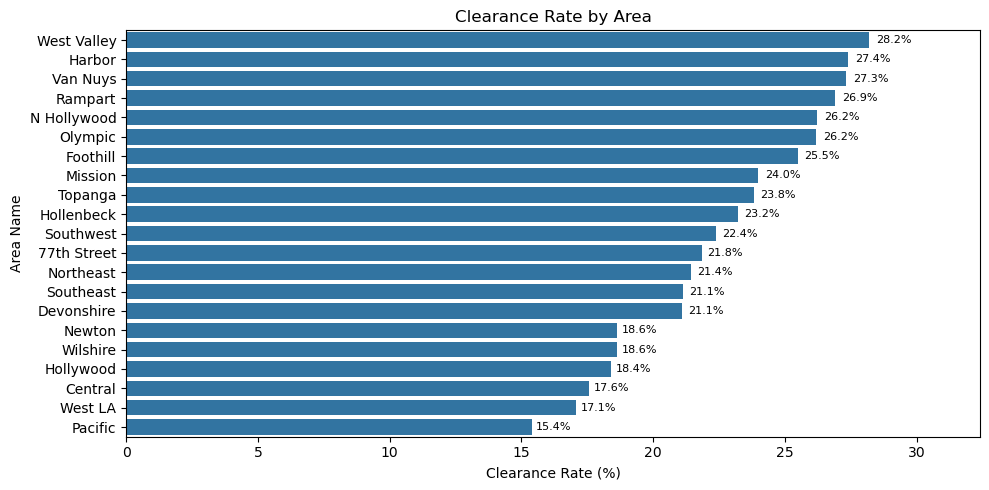

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = sns.barplot(
    data=area_pivot,
    x='clearance_rate',
    y='AREA NAME',
    ax=ax
)

for bar, value in zip(ax.patches, area_pivot['clearance_rate']):
    ax.text(
        bar.get_width() + bar.get_width() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center', ha='left',
        fontsize=8
    )

ax.margins(x=0.15)
ax.set_title('Clearance Rate by Area')
ax.set_xlabel('Clearance Rate (%)')
ax.set_ylabel('Area Name')

plt.tight_layout()
plt.savefig('../../outputs/09_eda_block5/29_barh_clearance_rate_by_area.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q5.1 — Clearance Rate per area LAPD

Il clearance rate complessivo varia tra il 15.4% (Pacific) e il 28.2% 
(West Valley), con un range di soli ~13 punti percentuali tra l'area 
migliore e la peggiore.

**Aree con clearance rate più alto**:
- West Valley: 28.2%
- Harbor: 27.4%
- Van Nuys: 27.3%
- Rampart: 26.9%

**Aree con clearance rate più basso**:
- Pacific: 15.4%
- West LA: 17.1%
- Central: 17.6%
- Hollywood: 18.4%

**Dato rilevante**: le aree con il maggior volume di crimini nei blocchi 
precedenti (77th Street, Southeast, Southwest) si collocano a metà 
classifica nel clearance rate (21.8%, 21.1%, 22.4%). Non emerge una 
correlazione diretta tra alto volume di crimini e basso tasso di 
risoluzione.

**Nota metodologica**: il range ristretto tra le aree (~13 punti) 
suggerisce che il clearance rate è influenzato principalmente dalla 
tipologia di crimine presente in ogni area piuttosto che dall'efficacia 
investigativa locale. Il grafico per categoria di crimine che segue 
chiarirà questo punto.

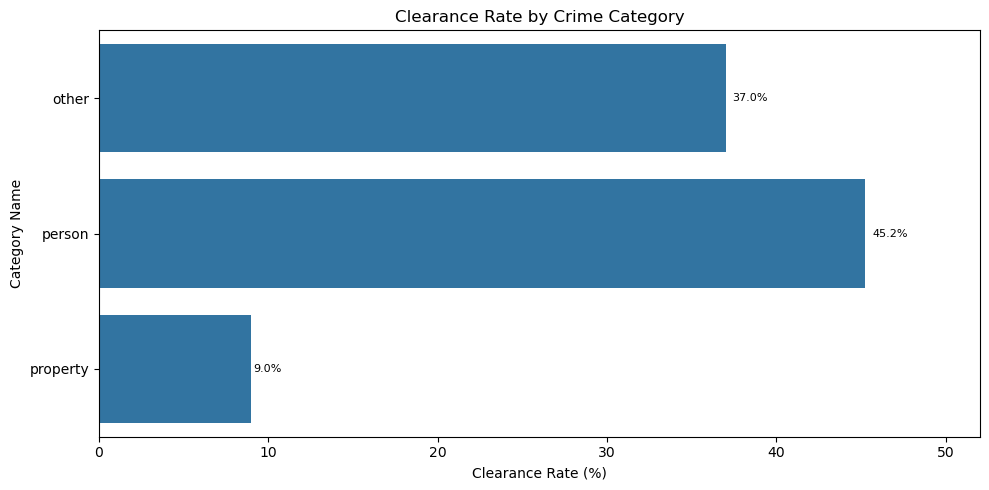

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = sns.barplot(
    data=category_pivot,
    x='clearance_rate',
    y='crime_category',
    ax=ax
)

for bar, value in zip(ax.patches, category_pivot['clearance_rate']):
    ax.text(
        bar.get_width() + bar.get_width() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center', ha='left',
        fontsize=8
    )

ax.margins(x=0.15)
ax.set_title('Clearance Rate by Crime Category')
ax.set_xlabel('Clearance Rate (%)')
ax.set_ylabel('Category Name')

plt.tight_layout()
plt.savefig('../../outputs/09_eda_block5/30_barh_clearance_rate_by_crime_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q5.1 — Clearance Rate per categoria di crimine

- **Person**: 45.2% — quasi la metà dei crimini contro la persona 
  viene risolta.
- **Other**: 37.0% — categoria residuale con tasso intermedio, 
  coerente con il fatto che include crimini dove il sospettato è 
  spesso già noto alle autorità (disturbo della pace, false denunce, 
  oltraggio alla corte).
- **Property**: 9.0% — solo 1 crimine su 11 contro la proprietà 
  viene risolto.

**Dato chiave**: il divario tra Person e Property è di oltre 36 punti 
percentuali — il clearance rate dei crimini contro la persona è 5 volte 
superiore a quello dei crimini contro la proprietà.

**Connessione con il grafico precedente**: questo dato spiega il range 
ristretto osservato nel clearance rate per area. Poiché i crimini 
Property rappresentano il 63% del dataset, il loro basso tasso di 
risoluzione comprime strutturalmente il clearance rate complessivo di 
tutte le aree, indipendentemente dall'efficacia investigativa locale.

**Nota metodologica**: il basso clearance rate dei crimini Property 
non è necessariamente indicativo di scarsa efficacia investigativa. 
Furti, scassi e vandalismi sono strutturalmente più difficili da 
risolvere per l'assenza frequente di testimoni o prove dirette. 
Il dato va contestualizzato prima di trarre conclusioni sull'operato 
delle forze dell'ordine.

### Q5.2 - Analisi del report delay

In [24]:
q52_df = df[['report_delay', 'crime_category']].copy()
q52_df = q52_df[q52_df['report_delay'] <= 365]  
q52_df = q52_df[q52_df['report_delay'] >= 0]    
print(q52_df.shape)
print(q52_df['report_delay'].describe())

(3040664, 2)
count    3.040664e+06
mean     7.370273e+00
std      2.981563e+01
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      3.650000e+02
Name: report_delay, dtype: float64


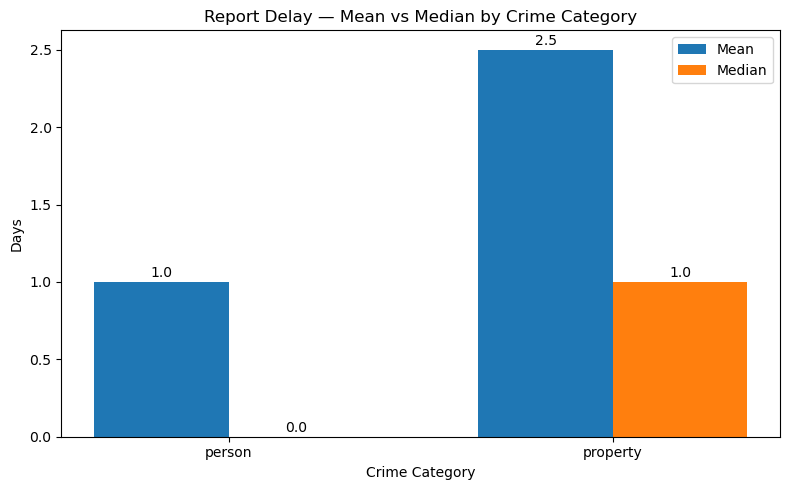

In [36]:
categories = ['person', 'property']
means = [1.0, 2.5]
medians = [0.0, 1.0]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, means, width, label='Mean')
ax.bar(x + width/2, medians, width, label='Median')

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.1f}',
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('Report Delay — Mean vs Median by Crime Category')
ax.set_xlabel('Crime Category')
ax.set_ylabel('Days')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
plt.savefig('../../outputs/09_eda_block5/31_barplot_report_delay_mean_median.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [37]:
total = len(df[df['crime_category'] != 'other'])
filtered = len(q52_df_filtered)
excluded = total - filtered
print(f'Totale records: {total:,}')
print(f'Records filtrati (<=30 giorni): {filtered:,}')
print(f'Records esclusi (>30 giorni): {excluded:,}')
print(f'Percentuale esclusa: {excluded/total*100:.1f}%')

Totale records: 3,031,776
Records filtrati (<=30 giorni): 2,834,639
Records esclusi (>30 giorni): 197,137
Percentuale esclusa: 6.5%


### Osservazioni Q5.2 — Report Delay per categoria di crimine

**Nota metodologica**: l'analisi è limitata ai crimini con report delay 
compreso tra 0 e 365 giorni (3.040.664 record). I casi con delay superiore 
all'anno rappresentano situazioni eccezionali escluse per mantenere 
la significatività statistica. Il confronto per categoria esclude "Other" 
e copre 3.031.776 record totali, di cui 2.834.639 con delay ≤ 30 giorni 
(93.5%) e 197.137 con delay tra 31 e 365 giorni (6.5%).

**Crimini contro la persona**:
- Media: 1.0 giorno
- Mediana: 0.0 giorni — vengono denunciati lo stesso giorno in cui avvengono

**Crimini contro la proprietà**:
- Media: 2.5 giorni
- Mediana: 1.0 giorno

**Pattern generale**: entrambe le categorie mostrano ritardi molto 
contenuti. La grande maggioranza dei crimini viene denunciata entro 
1-2 giorni dall'evento.

**Differenza tra le categorie**: i crimini contro la persona vengono 
denunciati più rapidamente di quelli contro la proprietà. Questo è 
coerente con la natura dei due tipi di reato: le aggressioni e i reati 
violenti sono eventi traumatici che si denunciano immediatamente, mentre 
i furti e gli scassi vengono spesso scoperti con un ritardo.